# 📦 Notebook 1: Data Inspection, Visualization & Cleaning
### SupplyChain-AI-Agent | AIML Lab Assignment

**Goal:** Understand the raw DataCo Supply Chain dataset, visualize key patterns, handle missing values, and produce a clean CSV for the next pipeline stage.

**Output:** `data/cleaned_data.csv`

---

## 0. Imports & Setup

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Nice plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


---
## 1. Load the Dataset

In [28]:
# ── Load raw dataset ──────────────────────────────────────────────────────────
DATA_PATH = '../Datasets/DataCoSupplyChainDataset.csv'

df = pd.read_csv(DATA_PATH, encoding='latin-1')   # latin-1 handles special chars in this dataset

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset loaded: 180,519 rows × 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


---
## 2. Data Inspection
### 2.1 Shape, Types & Basic Info

In [29]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print("="*55)

# Data types summary
dtype_counts = df.dtypes.value_counts()
print("\nColumn dtypes breakdown:")
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):<12} → {count} columns")

  DATASET OVERVIEW
  Rows         : 180,519
  Columns      : 53
  Memory usage : 313.44 MB

Column dtypes breakdown:
  str          → 24 columns
  float64      → 15 columns
  int64        → 14 columns


In [30]:
# Full column list with dtypes
print("All columns and their data types:\n")
col_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})
col_info.set_index('Column', inplace=True)
col_info

All columns and their data types:



,Dtype,Non-Null Count,Null Count,Unique Values
Column,,,,
Type,str,180519,0,4
Days for shipping (real),int64,180519,0,7
Days for shipment (scheduled),int64,180519,0,4
Benefit per order,float64,180519,0,21998
Sales per customer,float64,180519,0,2927
Delivery Status,str,180519,0,4
Late_delivery_risk,int64,180519,0,2
Category Id,int64,180519,0,51
Category Name,str,180519,0,50


### 2.2 Statistical Summary

In [31]:
# Numeric columns summary
print("── Numeric Columns Summary ──")
df.describe().T.round(2)

── Numeric Columns Summary ──


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.0,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.0,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.0,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.0,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.0,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


In [32]:
# Categorical columns summary
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"── Categorical Columns ({len(cat_cols)} total) ──\n")
for col in cat_cols:
    top_vals = df[col].value_counts().head(3).to_dict()
    print(f"  {col:<45} | unique={df[col].nunique():<6} | top3={top_vals}")

── Categorical Columns (24 total) ──

  Type                                          | unique=4      | top3={'DEBIT': 69295, 'TRANSFER': 49883, 'PAYMENT': 41725}
  Delivery Status                               | unique=4      | top3={'Late delivery': 98977, 'Advance shipping': 41592, 'Shipping on time': 32196}
  Category Name                                 | unique=50     | top3={'Cleats': 24551, "Men's Footwear": 22246, "Women's Apparel": 21035}
  Customer City                                 | unique=563    | top3={'Caguas': 66770, 'Chicago': 3885, 'Los Angeles': 3417}
  Customer Country                              | unique=2      | top3={'EE. UU.': 111146, 'Puerto Rico': 69373}
  Customer Email                                | unique=1      | top3={'XXXXXXXXX': 180519}
  Customer Fname                                | unique=782    | top3={'Mary': 65150, 'James': 1835, 'Robert': 1759}
  Customer Lname                                | unique=1109   | top3={'Smith': 64104, 'Johnson

### 2.3 Missing Values Analysis

In [33]:
# Missing value counts & percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found!")
else:
    print(f"Columns with missing values: {len(missing_df)}\n")
    print(missing_df.to_string())

Columns with missing values: 4

                     Missing Count  Missing %
Product Description         180519     100.00
Order Zipcode               155679      86.24
Customer Zipcode                 3       0.00
Customer Lname                   8       0.00


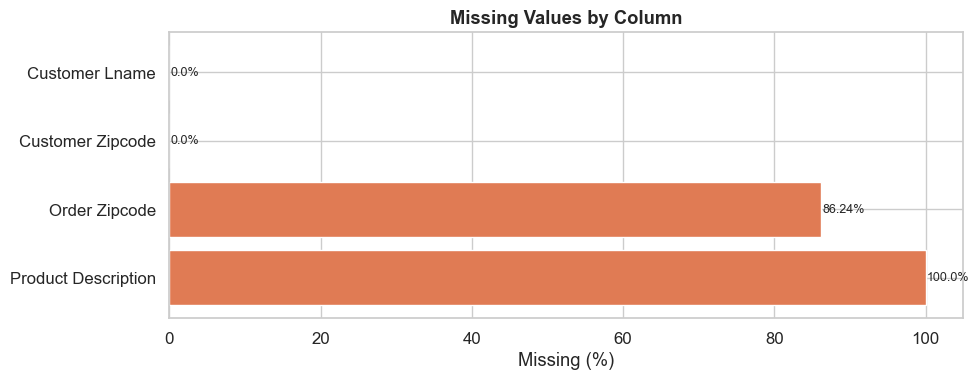

In [34]:
# Visualize missing values
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#E07B54', edgecolor='white')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column', fontweight='bold')
    for bar, val in zip(bars, missing_df['Missing %']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No missing value plot needed — dataset is complete.")

### 2.4 Duplicate Rows

In [35]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count:,} ({dup_count/len(df)*100:.2f}%)")

Duplicate rows found: 0 (0.00%)


---
## 3. Exploratory Visualizations
### 3.1 Target Variable — Late Delivery Distribution

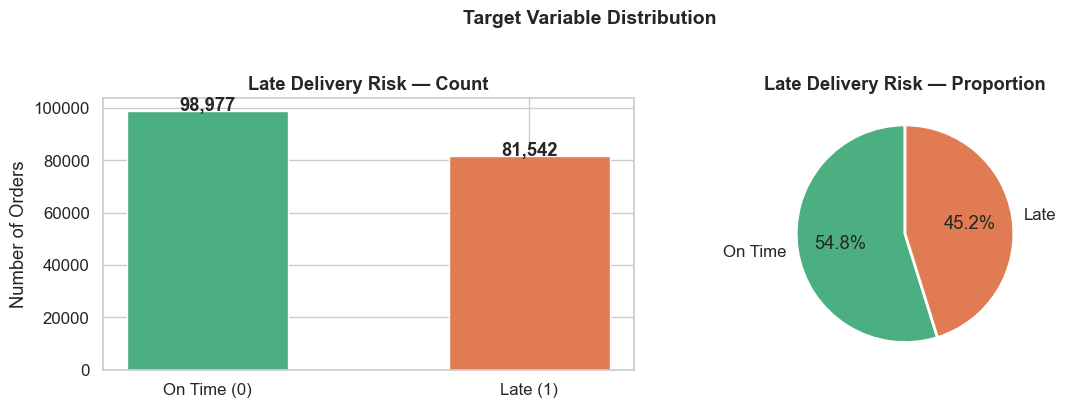


Class balance:
                    count  percentage
Late_delivery_risk                   
1                   98977       54.83
0                   81542       45.17


In [36]:
# The key target: 'Late_delivery_risk' (0 = on time, 1 = late)
target_col = 'Late_delivery_risk'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df[target_col].value_counts()
axes[0].bar(['On Time (0)', 'Late (1)'], counts.values,
            color=['#4CAF82', '#E07B54'], edgecolor='white', width=0.5)
axes[0].set_title('Late Delivery Risk — Count', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['On Time', 'Late'],
            autopct='%1.1f%%', colors=['#4CAF82', '#E07B54'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Late Delivery Risk — Proportion', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass balance:")
print(counts.to_frame().assign(percentage=(counts/len(df)*100).round(2)))

### 3.2 Shipping Mode vs Late Delivery

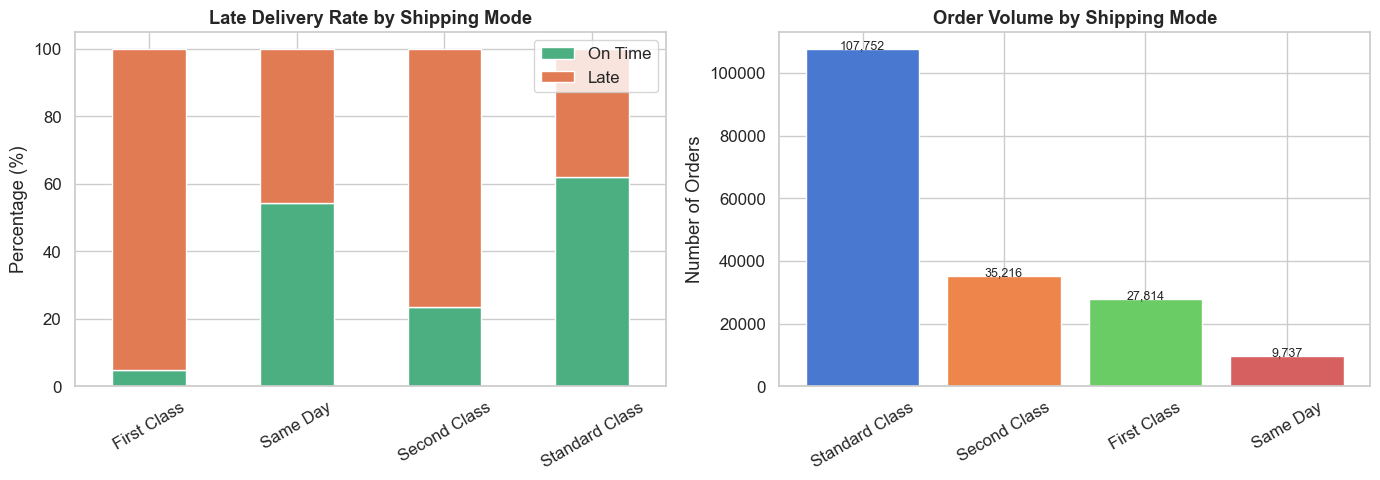

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: Shipping mode vs Late delivery
ship_late = df.groupby('Shipping Mode')[target_col].value_counts(normalize=True).unstack().fillna(0) * 100
ship_late.columns = ['On Time', 'Late']
ship_late[['On Time', 'Late']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#4CAF82', '#E07B54'], edgecolor='white'
)
axes[0].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='upper right')

# Order volume by shipping mode
ship_count = df['Shipping Mode'].value_counts()
axes[1].bar(ship_count.index, ship_count.values,
            color=sns.color_palette('muted', len(ship_count)), edgecolor='white')
axes[1].set_title('Order Volume by Shipping Mode', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(ship_count.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3.3 Order Region & Market Distribution

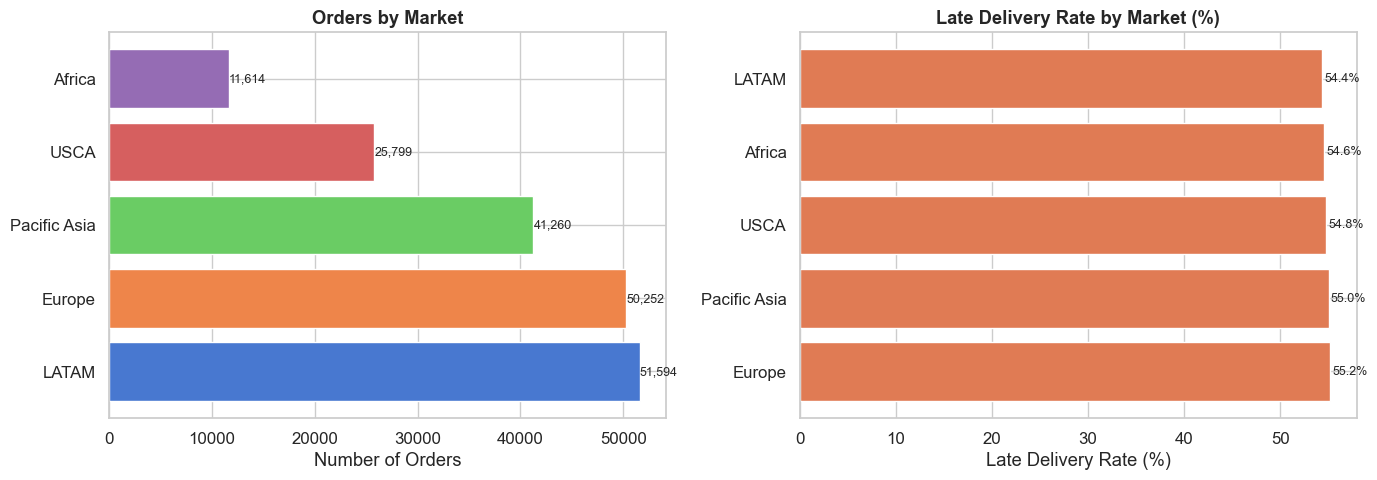

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Market distribution
mkt = df['Market'].value_counts()
axes[0].barh(mkt.index, mkt.values, color=sns.color_palette('muted', len(mkt)))
axes[0].set_title('Orders by Market', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(mkt.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# Late delivery rate by market
mkt_late = df.groupby('Market')[target_col].mean().sort_values(ascending=False) * 100
axes[1].barh(mkt_late.index, mkt_late.values, color='#E07B54')
axes[1].set_title('Late Delivery Rate by Market (%)', fontweight='bold')
axes[1].set_xlabel('Late Delivery Rate (%)')
for i, v in enumerate(mkt_late.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3.4 Delivery Time & Scheduled Days Analysis

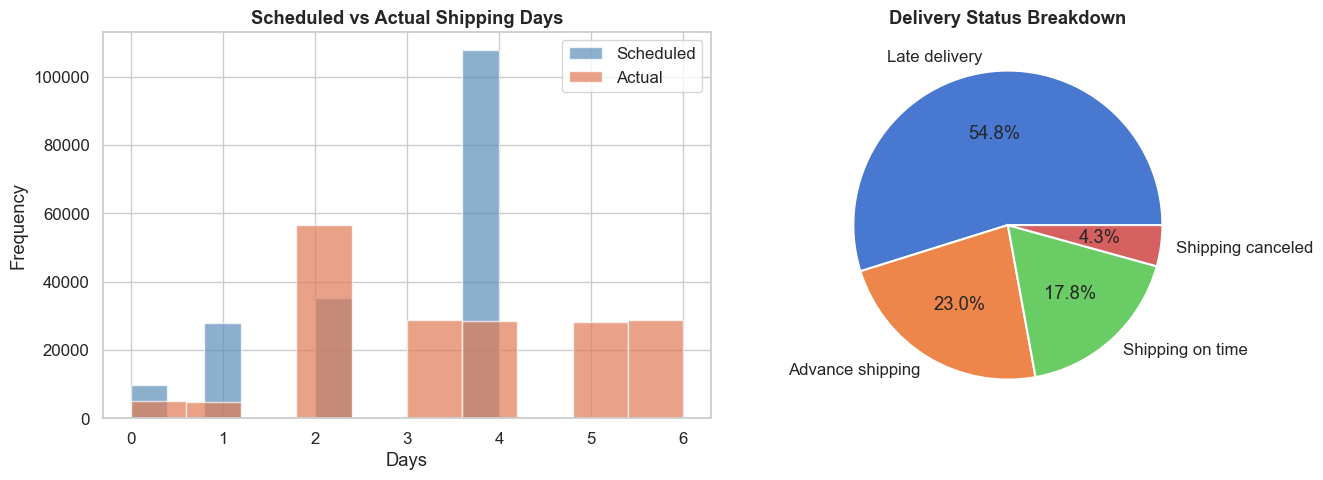

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Days for shipment (scheduled vs real)
axes[0].hist(df['Days for shipment (scheduled)'].dropna(), bins=10,
             alpha=0.7, color='#5B8DB8', label='Scheduled', edgecolor='white')
axes[0].hist(df['Days for shipping (real)'].dropna(), bins=10,
             alpha=0.7, color='#E07B54', label='Actual', edgecolor='white')
axes[0].set_title('Scheduled vs Actual Shipping Days', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Delivery status breakdown
status_counts = df['Delivery Status'].value_counts()
colors = sns.color_palette('muted', len(status_counts))
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Delivery Status Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.5 Sales & Profit Distributions

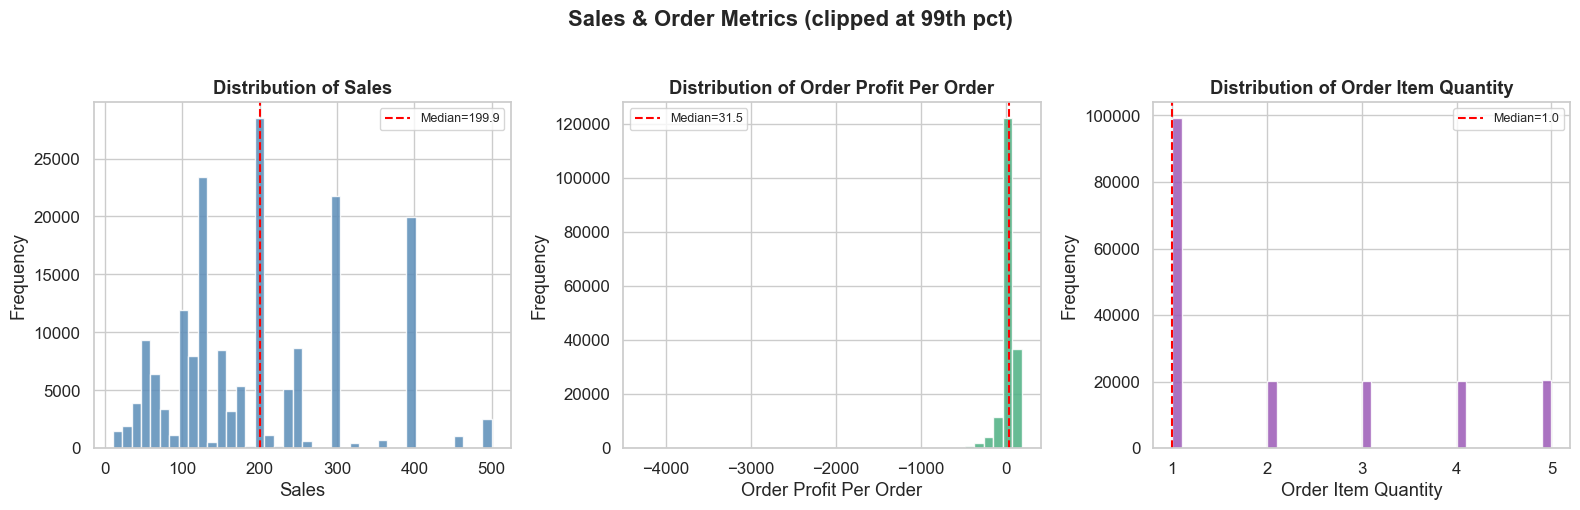

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

numeric_targets = ['Sales', 'Order Profit Per Order', 'Order Item Quantity']
colors = ['#5B8DB8', '#4CAF82', '#9B59B6']

for ax, col, color in zip(axes, numeric_targets, colors):
    data = df[col].dropna()
    # Clip extreme outliers for visualization (99th percentile)
    upper = data.quantile(0.99)
    data_clipped = data[data <= upper]
    ax.hist(data_clipped, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={data.median():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Sales & Order Metrics (clipped at 99th pct)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.6 Top Product Categories

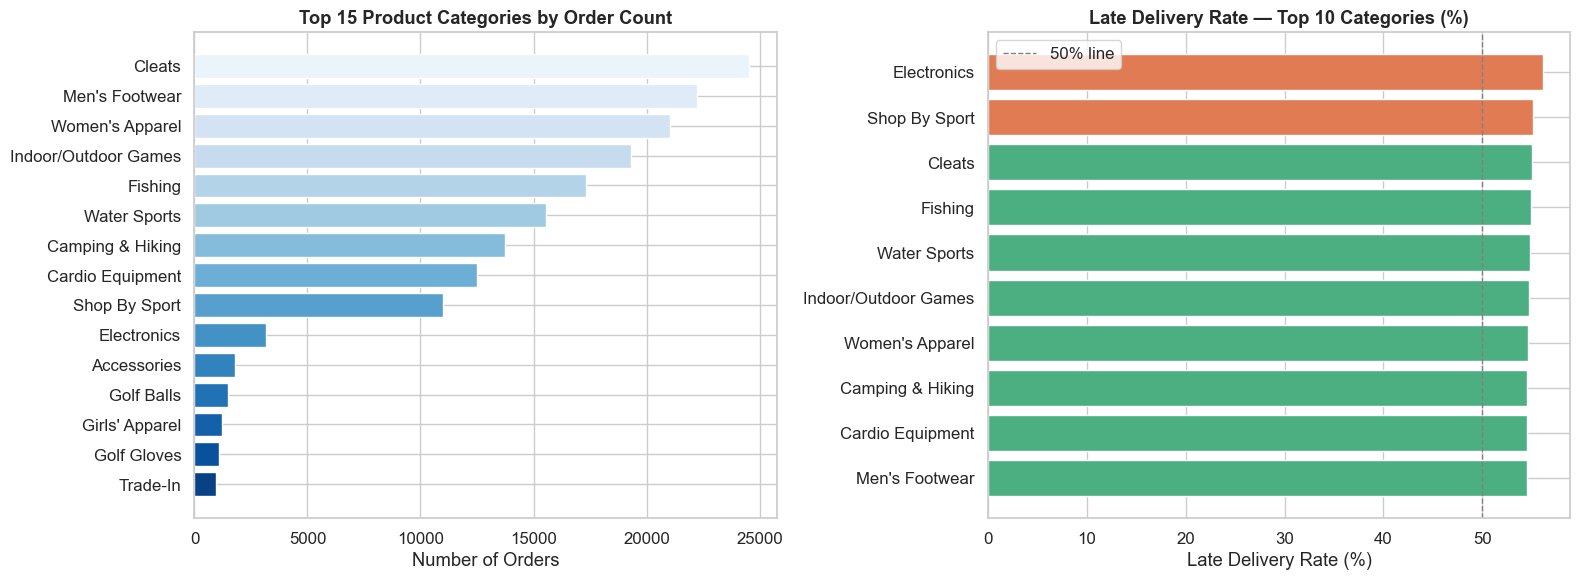

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 categories by order count
top_cats = df['Category Name'].value_counts().head(15)
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1],
             color=sns.color_palette('Blues_r', 15))
axes[0].set_title('Top 15 Product Categories by Order Count', fontweight='bold')
axes[0].set_xlabel('Number of Orders')

# Late delivery rate by top 10 categories
top10_cats = top_cats.head(10).index
cat_late = (df[df['Category Name'].isin(top10_cats)]
            .groupby('Category Name')[target_col]
            .mean().sort_values() * 100)
colors_late = ['#4CAF82' if v < 55 else '#E07B54' for v in cat_late.values]
axes[1].barh(cat_late.index, cat_late.values, color=colors_late)
axes[1].set_title('Late Delivery Rate — Top 10 Categories (%)', fontweight='bold')
axes[1].set_xlabel('Late Delivery Rate (%)')
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1, label='50% line')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.7 Order Trends Over Time

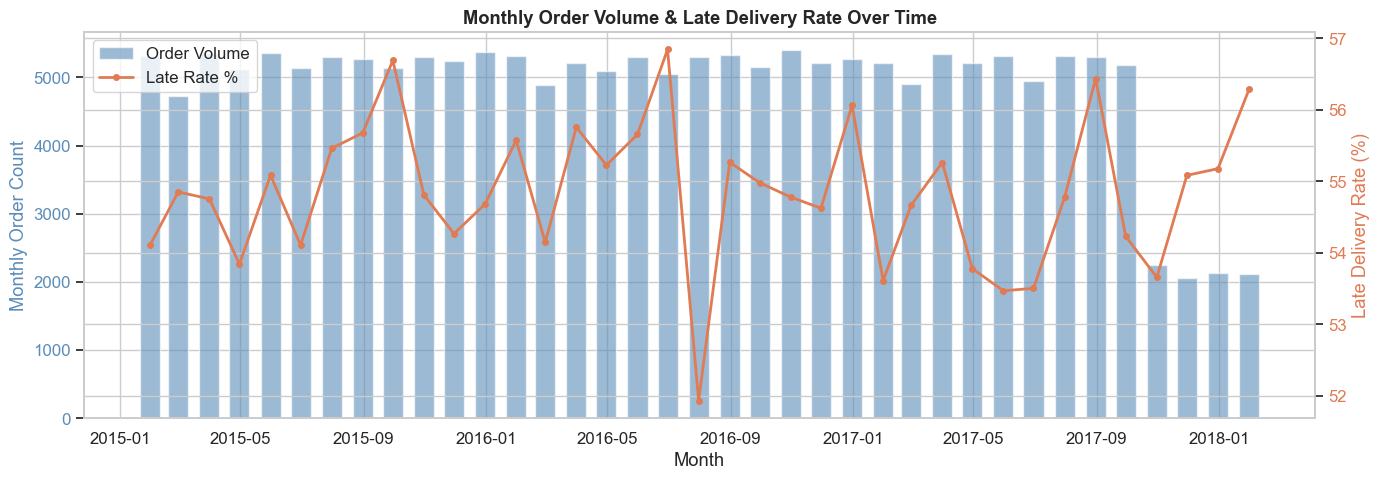

In [42]:
# Parse dates
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')

# Monthly orders and late delivery rate
monthly = df.resample('ME', on='order date (DateOrders)').agg(
    order_count=(target_col, 'count'),
    late_rate=(target_col, 'mean')
).dropna()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly.index, monthly['order_count'], color='#5B8DB8',
        alpha=0.6, label='Order Volume', width=20)
ax1.set_ylabel('Monthly Order Count', color='#5B8DB8')
ax1.tick_params(axis='y', labelcolor='#5B8DB8')

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['late_rate'] * 100, color='#E07B54',
         linewidth=2, marker='o', markersize=4, label='Late Rate %')
ax2.set_ylabel('Late Delivery Rate (%)', color='#E07B54')
ax2.tick_params(axis='y', labelcolor='#E07B54')

ax1.set_title('Monthly Order Volume & Late Delivery Rate Over Time', fontweight='bold')
ax1.set_xlabel('Month')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 3.8 Correlation Heatmap (Numeric Features)

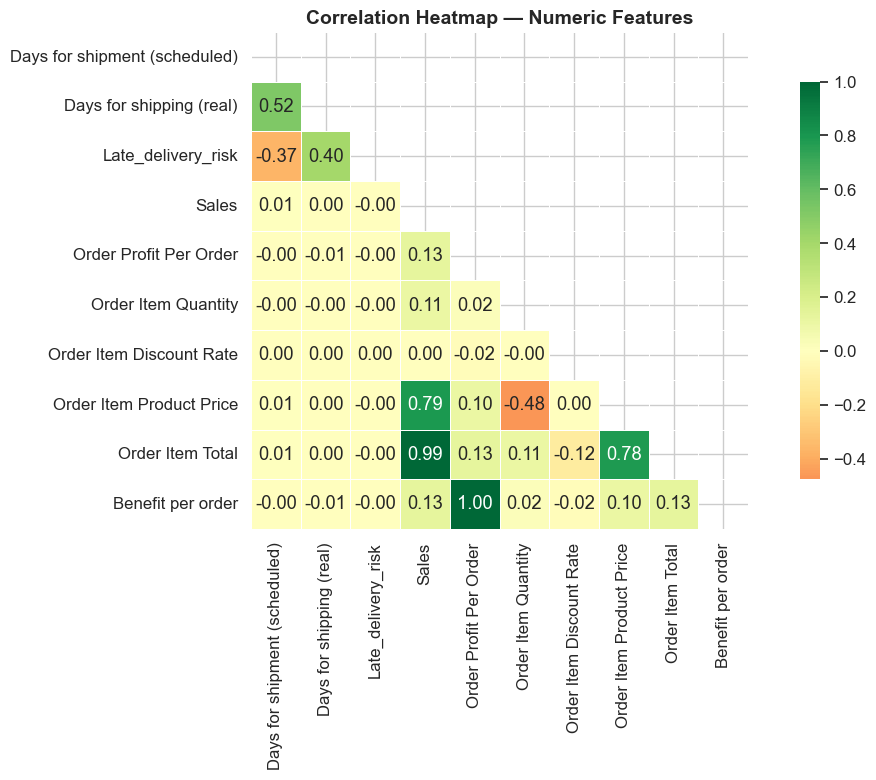


Top correlations with 'Late_delivery_risk':
Days for shipping (real)         0.401
Days for shipment (scheduled)   -0.369
Order Item Total                -0.004
Benefit per order               -0.004
Order Profit Per Order          -0.004
Sales                           -0.004
Order Item Product Price        -0.002
Order Item Discount Rate         0.000
Order Item Quantity             -0.000
Name: Late_delivery_risk, dtype: float64


In [43]:
# Select key numeric columns for correlation
num_cols = [
    'Days for shipment (scheduled)', 'Days for shipping (real)',
    'Late_delivery_risk', 'Sales', 'Order Profit Per Order',
    'Order Item Quantity', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Total',
    'Benefit per order'
]
# Keep only cols that exist in this dataset
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Print top correlations with target
print("\nTop correlations with 'Late_delivery_risk':")
print(corr[target_col].drop(target_col).sort_values(key=abs, ascending=False).round(3))

### 3.9 Outlier Detection — Boxplots

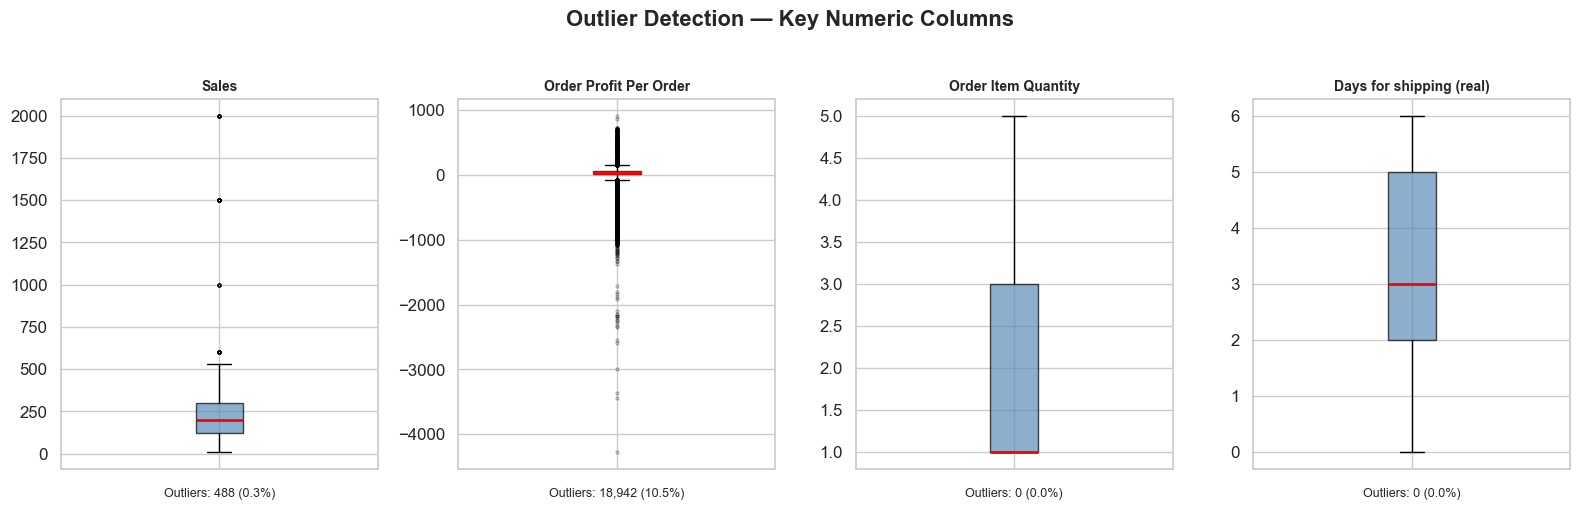

In [44]:
outlier_cols = ['Sales', 'Order Profit Per Order', 'Order Item Quantity',
                'Days for shipping (real)']
outlier_cols = [c for c in outlier_cols if c in df.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))

for ax, col in zip(axes, outlier_cols):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#5B8DB8', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticklabels([])
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_xlabel(f'Outliers: {outliers:,} ({outliers/len(data)*100:.1f}%)', fontsize=9)

plt.suptitle('Outlier Detection — Key Numeric Columns', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Data Cleaning
### 4.1 Drop Irrelevant / Redundant Columns

In [45]:
# Columns that leak the target or are purely administrative / not useful for ML
cols_to_drop = [
    'Product Description',    # free text, not useful
    'Product Image',          # URL, not useful
    'Customer Fname',         # PII
    'Customer Lname',         # PII
    'Customer Email',         # PII
    'Customer Password',      # PII / security
    'Order Zipcode',          # too granular, many nulls
]

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining shape: {df_clean.shape}")

Dropped 7 columns: ['Product Description', 'Product Image', 'Customer Fname', 'Customer Lname', 'Customer Email', 'Customer Password', 'Order Zipcode']
Remaining shape: (180519, 46)


### 4.2 Handle Missing Values

In [46]:
print("Missing values before cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print()

# ── Strategy ─────────────────────────────────────────────────────────────────
# Numeric  → fill with median (robust to outliers)
# Categorical → fill with mode

num_cols_clean = df_clean.select_dtypes(include='number').columns
cat_cols_clean = df_clean.select_dtypes(include='object').columns

for col in num_cols_clean:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  [Numeric] '{col}' → filled with median={median_val:.2f}")

for col in cat_cols_clean:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"  [Categorical] '{col}' → filled with mode='{mode_val}'")

print(f"\n✅ Missing values after cleaning: {df_clean.isnull().sum().sum()}")

Missing values before cleaning:
Customer Zipcode    3
dtype: int64

  [Numeric] 'Customer Zipcode' → filled with median=19380.00

✅ Missing values after cleaning: 0


### 4.3 Remove Duplicate Rows

In [47]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after:,} duplicate rows.")
print(f"Remaining rows: {after:,}")

Removed 0 duplicate rows.
Remaining rows: 180,519


### 4.4 Fix Data Types

In [48]:
# Parse date columns properly
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        print(f"  '{col}' → converted to datetime")

# Convert obvious booleans/flags stored as float to int
flag_cols = ['Late_delivery_risk']
for col in flag_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(int)
        print(f"  '{col}' → converted to int")

print("\n✅ Data types fixed.")

  'order date (DateOrders)' → converted to datetime
  'shipping date (DateOrders)' → converted to datetime
  'Late_delivery_risk' → converted to int

✅ Data types fixed.


### 4.5 Clip Extreme Outliers in Key Numeric Columns

In [49]:
# We clip (not remove) at 1st–99th percentile to reduce outlier influence
clip_cols = ['Sales', 'Order Profit Per Order', 'Order Item Total', 'Benefit per order']
clip_cols = [c for c in clip_cols if c in df_clean.columns]

for col in clip_cols:
    lo, hi = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    before_range = df_clean[col].max() - df_clean[col].min()
    df_clean[col] = df_clean[col].clip(lo, hi)
    after_range = df_clean[col].max() - df_clean[col].min()
    print(f"  '{col}': clipped to [{lo:.2f}, {hi:.2f}] | range {before_range:.2f} → {after_range:.2f}")

print("\n✅ Outliers clipped.")

  'Sales': clipped to [24.99, 499.95] | range 1990.00 → 474.96
  'Order Profit Per Order': clipped to [-415.60, 184.23] | range 5186.78 → 599.83
  'Order Item Total': clipped to [22.49, 464.95] | range 1932.50 → 442.46
  'Benefit per order': clipped to [-415.60, 184.23] | range 5186.78 → 599.83

✅ Outliers clipped.


### 4.6 Standardise String Columns

In [50]:
# Strip whitespace and title-case important categoricals
str_cols = ['Category Name', 'Department Name', 'Customer Segment',
            'Shipping Mode', 'Order Status', 'Market', 'Delivery Status']
str_cols = [c for c in str_cols if c in df_clean.columns]

for col in str_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

print(f"Standardised {len(str_cols)} string columns: {str_cols}")

Standardised 7 string columns: ['Category Name', 'Department Name', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Market', 'Delivery Status']


---
## 5. Post-Cleaning Summary

In [51]:
print("=" * 55)
print("  CLEANING SUMMARY")
print("=" * 55)
print(f"  Original shape  : {df.shape}")
print(f"  Cleaned shape   : {df_clean.shape}")
print(f"  Rows removed    : {df.shape[0] - df_clean.shape[0]:,}")
print(f"  Cols removed    : {df.shape[1] - df_clean.shape[1]}")
print(f"  Missing values  : {df_clean.isnull().sum().sum()}")
print(f"  Duplicate rows  : {df_clean.duplicated().sum()}")
print("=" * 55)

df_clean.head(3)

  CLEANING SUMMARY
  Original shape  : (180519, 53)
  Cleaned shape   : (180519, 46)
  Rows removed    : 0
  Cols removed    : 7
  Missing values  : 0
  Duplicate rows  : 0


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance Shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,Complete,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late Delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,Pending,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping On Time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,Closed,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class


---
## 6. Save Cleaned Data

In [52]:
OUTPUT_PATH = '../Datasets/cleaned_data.csv'

df_clean.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Cleaned data saved to: {OUTPUT_PATH}")
print(f"   Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print("\n→ Next step: Run Notebook 2 — Feature Engineering")

✅ Cleaned data saved to: ../Datasets/cleaned_data.csv
   Shape: 180,519 rows × 46 columns

→ Next step: Run Notebook 2 — Feature Engineering
